In [ ]:
########################################################
# This Routine Plots the 2D and 3D light profile of the#
# brightest star in a field and saves the plots in the #
# same directory as the data                           #
########################################################

Average FWHM: 1.45 arcsec
Plot saved to C:\Users\Observatory\Exo\Data\Standard-stars\BD+210607_10_08\BD210607-g_2024_10_08_exp00.00.05.000_1x1_Low_1_2D_light_profile.png


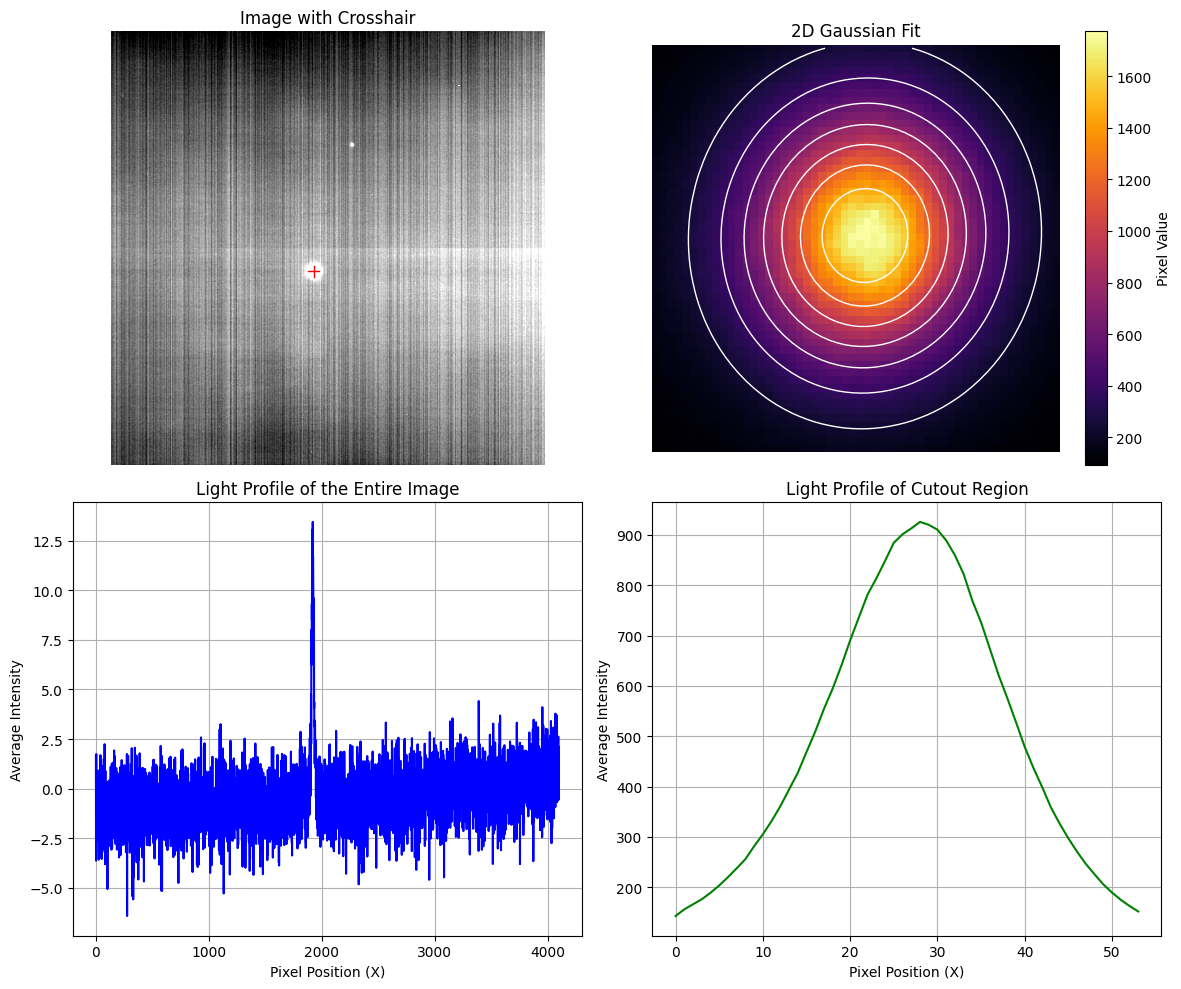

In [74]:
import astropy
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from convenience_functions import show_image 
from photutils.detection import DAOStarFinder
from astropy.stats import mad_std
from astropy.modeling import models, fitting
from astropy.stats import sigma_clipped_stats
from mpl_toolkits.mplot3d import Axes3D
import os # Import for file operations

# Load the FITS file
filename = "C:\\Users\\Observatory\\Exo\\Data\\Standard-stars\\BD+210607_10_08\\BD210607-g_2024_10_08_exp00.00.05.000_1x1_Low_1.fit"
hdul = fits.open(filename)
image_data = hdul[0].data
hdul.close()

# Star finding
bkg_sigma = mad_std(image_data)
daofind = DAOStarFinder(fwhm=3.0, threshold=5.*bkg_sigma)
sources = daofind(image_data)

def show_image(image_data, cmap='gray', percl=90, fig=None, ax=None):
    """Displays an image with percentile contrast scaling using matplotlib.

    Args:
        image_data (numpy.ndarray): The image data to display.
        cmap (str, optional): The colormap to use. Defaults to 'gray'.
        percl (float, optional): The percentile for contrast scaling. Defaults to 90.
        fig (matplotlib.figure.Figure, optional): The figure object to plot on. Defaults to None.
        ax (matplotlib.axes._axes.Axes, optional): The axes object to plot on.  If None, a new one is created.
    """
    vmin, vmax = np.percentile(image_data, (100 - percl, percl))

    if ax is None and fig is None:
        fig, ax = plt.subplots(1) # Create figure and axes if neither are provided
    elif ax is None and fig is not None:
        ax = fig.add_subplot(111) # Add subplot to existing figure if only fig is provided
    elif fig is None and ax is not None:
        fig = ax.figure # Get the figure from the axes object.


    ax.imshow(image_data, cmap=cmap, vmin=vmin, vmax=vmax, origin='lower')  #Crucially uses ax.imshow
    ax.axis('off') # Turn off axis labels

    return fig, ax  # Return both figure and axes object


brightest_star = sources[np.argmax(sources['flux'])]
x_centroid, y_centroid = brightest_star['xcentroid'], brightest_star['ycentroid']

Size_of_the_cutout_region=30
size = Size_of_the_cutout_region

### Change 1.1 to change the size of the Cutout region###
x_min, x_max = int(x_centroid - size//1.1), int(x_centroid + size//1.1)
y_min, y_max = int(y_centroid - size//1.1), int(y_centroid + size//1.1)
cutout = image_data[y_min:y_max, x_min:x_max]
# Create coordinate grids
y, x = np.mgrid[:cutout.shape[0], :cutout.shape[1]]

# Define a 2D Gaussian model
g_init = models.Gaussian2D(amplitude=cutout.max(),
                           x_mean=size//2, y_mean=size//2,
                           x_stddev=3, y_stddev=3)

# Fit the model to the cutout data
fitter = fitting.LevMarLSQFitter()
g_fit = fitter(g_init, x, y, cutout)

# Calculate FWHM using the Gaussian relation: FWHM = 2.355 * sigma
fwhm_x = 2.355 * g_fit.x_stddev.value
fwhm_y = 2.355 * g_fit.y_stddev.value
fwhm_avg = (((fwhm_x + fwhm_y) / 2)*0.051)
print(f"Average FWHM: {fwhm_avg:.2f} arcsec")

# --- Calculate Light Profiles ---
# Calculate background statistics
mean_full, median_full, std_full = sigma_clipped_stats(image_data, sigma=3.0)

# Subtract the median to remove the background
data_sub_full = image_data - median_full

# Calculate the light profile by averaging along the y-axis
light_profile_full = np.mean(data_sub_full, axis=0)


# --- Code for Cutout Profile (Second Code) ---
### Change 1.1 to change the size of the Cutout region###
size = Size_of_the_cutout_region
x_min, x_max = int(x_centroid - size//1.1), int(x_centroid + size//1.1)
y_min, y_max = int(y_centroid - size//1.1), int(y_centroid + size//1.1)
data_sub_cutout = image_data[y_min:y_max, x_min:x_max]
light_profile_cutout = np.mean(data_sub_cutout, axis=0)


# --- Create the Figure and Subplots ---
fig, axs = plt.subplots(2, 2, figsize=(12, 10))  # 2 rows, 2 columns, increased figsize
# --- Plot 1: Image with Crosshair ---
# Display the image with a crosshair on the first subplot
axs[0, 0].imshow(image_data, cmap='gray', vmin=np.percentile(image_data, 10), vmax=np.percentile(image_data, 90), origin='lower')  # Using imshow directly and calculating vmin/vmax
axs[0, 0].set_title("Image with Crosshair")
axs[0, 0].axis('off')  # Turn off axis labels


# Add crosshair
crosshair_size = 50  # Adjust for desired crosshair size

axs[0, 0].plot([x_centroid - crosshair_size, x_centroid + crosshair_size], [y_centroid, y_centroid], 'r-', linewidth=1)  # Horizontal line
axs[0, 0].plot([x_centroid, x_centroid], [y_centroid - crosshair_size, y_centroid + crosshair_size], 'r-', linewidth=1)  # Vertical line


# --- Plot 2: Cutout with Gaussian Fit ---
# Plot the cutout with the Gaussian fit on the second subplot
im = axs[0, 1].imshow(cutout, cmap='inferno', origin='lower')
axs[0, 1].contour(g_fit(x, y), colors='white', linewidths=1)
axs[0, 1].set_title("2D Gaussian Fit")
axs[0, 1].axis('off')
fig.colorbar(im, ax=axs[0, 1], label="Pixel Value") # add colorbar to the second subplot


# --- Plot 3: Full Image Light Profile ---
axs[1, 0].plot(light_profile_full, 'b-')
axs[1, 0].set_xlabel('Pixel Position (X)')
axs[1, 0].set_ylabel('Average Intensity')
axs[1, 0].set_title('Light Profile of the Entire Image')
axs[1, 0].grid()


# --- Plot 4: Cutout Light Profile ---
axs[1, 1].plot(light_profile_cutout, 'g-')  # Use a different color (green)
axs[1, 1].set_xlabel('Pixel Position (X)')
axs[1, 1].set_ylabel('Average Intensity')
axs[1, 1].set_title('Light Profile of Cutout Region')
axs[1, 1].grid()


# Adjust layout to prevent overlap
plt.tight_layout()

# Construct the filename for saving the plot
base_filename = os.path.basename(filename)
name, ext = os.path.splitext(base_filename)
plot_filename = os.path.join(os.path.dirname(filename), f"{name}_2D_light_profile.png")

# Save the figure
try:
    plt.savefig(plot_filename)
    print(f"Plot saved to {plot_filename}")
except Exception as e:
    print(f"Error saving plot: {e}")

# Show the combined plot
plt.show()

In [61]:
#x
#y
# The numbers show how the average brightness changes as you move across the cutout region,
# from one side to the other.

light_profile_cutout

array([ 181.375     ,  184.875     ,  194.74166667,  202.75      ,
        207.00833333,  217.925     ,  225.83333333,  237.53333333,
        243.23333333,  260.54166667,  275.375     ,  286.04166667,
        303.725     ,  318.575     ,  337.24166667,  354.85833333,
        372.15      ,  403.69166667,  432.45      ,  465.15833333,
        488.78333333,  532.73333333,  572.81666667,  609.73333333,
        656.74166667,  720.96666667,  775.55833333,  846.90833333,
        925.775     , 1003.85      , 1102.91666667, 1206.34166667,
       1313.69166667, 1403.7       , 1496.5       , 1562.35833333,
       1642.15833333, 1704.76666667, 1756.94166667, 1817.80833333,
       1863.875     , 1912.9       , 1957.53333333, 1993.125     ,
       2047.6       , 2059.81666667, 2096.29166667, 2130.175     ,
       2151.76666667, 2167.31666667, 2186.50833333, 2177.875     ,
       2205.1       , 2215.3       , 2215.625     , 2240.45      ,
       2220.48333333, 2222.4       , 2230.10833333, 2207.925  

Plot saved to C:\Users\Observatory\Exo\Data\Standard-stars\BD+210607_10_08\BD210607-g_2024_10_08_exp00.00.05.000_1x1_Low_1_3D_light_profile.png


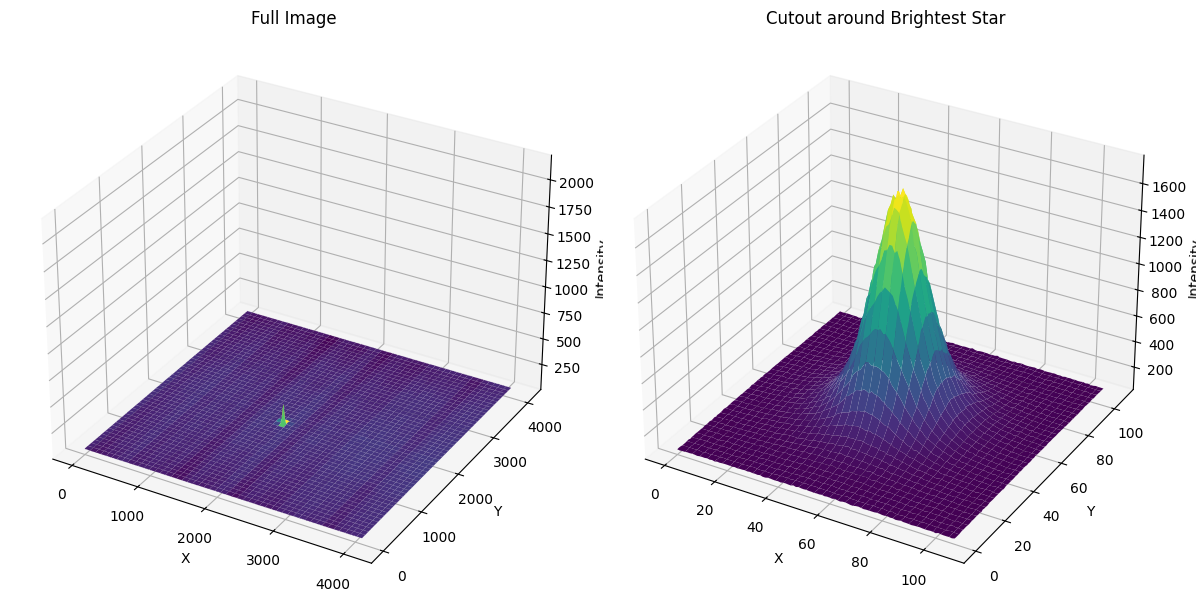

In [70]:
# --- Plot 1: Full Image ---
y1, x1 = np.mgrid[:image_data.shape[0], :image_data.shape[1]]

# --- Plot 2: Cutout around Brightest Star ---
bkg_sigma = mad_std(image_data)
daofind = DAOStarFinder(fwhm=3.0, threshold=5.*bkg_sigma)
sources = daofind(image_data)
if sources is not None:
    brightest_star = sources[np.argmax(sources['flux'])]
    x_centroid, y_centroid = brightest_star['xcentroid'], brightest_star['ycentroid']
    size = 60
    x_min, x_max = int(x_centroid - size//1.1), int(x_centroid + size//1.1)
    y_min, y_max = int(y_centroid - size//1.1), int(y_centroid + size//1.1)
    cutout = image_data[y_min:y_max, x_min:x_max]
    y2, x2 = np.mgrid[:cutout.shape[0], :cutout.shape[1]]

    # --- Create the Figure with Subplots ---
    fig = plt.figure(figsize=(12, 6))  # Adjust size as needed

    # Plot 1: Full Image
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.plot_surface(x1, y1, image_data, cmap='viridis')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Intensity')
    ax1.set_title('Full Image')

    # Plot 2: Cutout
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.plot_surface(x2, y2, cutout, cmap='viridis')
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.set_zlabel('Intensity')
    ax2.set_title('Cutout around Brightest Star')

    plt.tight_layout()

    # Construct the filename for saving the plot
    base_filename = os.path.basename(filename)
    name, ext = os.path.splitext(base_filename)
    plot_filename = os.path.join(os.path.dirname(filename), f"{name}_3D_light_profile.png")

    # Save the figure
    try:
        plt.savefig(plot_filename)
        print(f"Plot saved to {plot_filename}")
    except Exception as e:
        print(f"Error saving plot: {e}")

    plt.show()
else:
    print("No stars found in the image.")